In [4]:
import os
import math
import random
import json
import csv
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
import torchvision.transforms as T
from torchvision import models

print(f"torch:       {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device:      {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    print(f"VRAM:        {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cudnn.benchmark = True

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

torch:       2.7.1+cu118
torchvision: 0.22.1+cu118
device:      cuda
GPU:         NVIDIA GeForce GTX 1050
VRAM:        4.3 GB


In [6]:
@dataclass
class Config:
    data_dir: str = "./data"
    artifacts_dir: str = "./artifacts"
    figures_dir: str = "./artifacts/figures"

    dataset: str = "STL10"
    num_classes: int = 10
    image_size: int = 96
    image_size_resnet: int = 224
    val_fraction: float = 0.2

    seed: int = 42
    batch_size: int = 256
    epochs: int = 20
    lr: float = 1e-3

cfg = Config()

cfg



Config(data_dir='./data', artifacts_dir='./artifacts', figures_dir='./artifacts/figures', dataset='STL10', num_classes=10, image_size=96, image_size_resnet=224, val_fraction=0.2, seed=42, batch_size=256, epochs=20, lr=0.001)

In [7]:
transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(96, padding=12),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

transform_resnet = T.Compose([
    T.Resize(cfg.image_size_resnet),
    T.RandomHorizontalFlip(p=0.5),   # минимальная аугментация
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

transform_resnet_eval = T.Compose([
    T.Resize(cfg.image_size_resnet),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


In [13]:
import time

def load_stl10_to_gpu_safe(transform, split: str, device: torch.device, 
                            max_retries: int = 5, wait: float = 3.0):
    """
    Загружает STL10 с автоматическим retry при обрыве соединения.
    Если файл уже частично скачан — torchvision продолжит с того же места.
    """
    for attempt in range(1, max_retries + 1):
        try:
            ds = torchvision.datasets.STL10(
                root=cfg.data_dir,
                split=split,
                download=True,
                transform=transform,
            )
            # Если дошли сюда — датасет загружен, собираем тензоры
            X = torch.stack([ds[i][0] for i in range(len(ds))])
            y = torch.tensor([ds[i][1] for i in range(len(ds))], dtype=torch.long)
            
            X = X.to(device)
            y = y.to(device)
            
            print(f"  split={split:6s} | X: {tuple(X.shape)} | y: {tuple(y.shape)} "
                  f"| device: {X.device}")
            return X, y

        except (ConnectionResetError, OSError) as e:
            print(f"  [Попытка {attempt}/{max_retries}] Обрыв соединения: {e}")
            if attempt < max_retries:
                print(f"  Повтор через {wait} сек...")
                time.sleep(wait)
            else:
                raise RuntimeError("Не удалось скачать после нескольких попыток.") from e

def make_val_split(X_train, y_train, val_fraction: float, seed: int):

    n = X_train.shape[0]
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(n, generator=g)
    
    n_val = int(n * val_fraction)
    val_idx   = idx[:n_val]
    train_idx = idx[n_val:]
    
    return (X_train[train_idx], y_train[train_idx],
            X_train[val_idx],   y_train[val_idx])

In [15]:
print("=== Загрузка STL10 (base transform) ===")
X_train_raw, y_train_raw = load_stl10_to_gpu_safe(transform_base, "train", DEVICE)
X_test,      y_test      = load_stl10_to_gpu_safe(transform_base, "test",  DEVICE)

X_train, y_train, X_val, y_val = make_val_split(
    X_train_raw, y_train_raw, cfg.val_fraction, cfg.seed
)

print(f"\nПосле split:")
print(f"  train : {tuple(X_train.shape)}")
print(f"  val   : {tuple(X_val.shape)}")
print(f"  test  : {tuple(X_test.shape)}")

if DEVICE.type == "cuda":
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nVRAM использовано: {used:.2f} / {total:.1f} GB")



=== Загрузка STL10 (base transform) ===


100%|██████████| 2.64G/2.64G [15:29<00:00, 2.84MB/s]  


  split=train  | X: (5000, 3, 96, 96) | y: (5000,) | device: cuda:0
  split=test   | X: (8000, 3, 96, 96) | y: (8000,) | device: cuda:0

После split:
  train : (4000, 3, 96, 96)
  val   : (1000, 3, 96, 96)
  test  : (8000, 3, 96, 96)

VRAM использовано: 1.99 / 4.3 GB


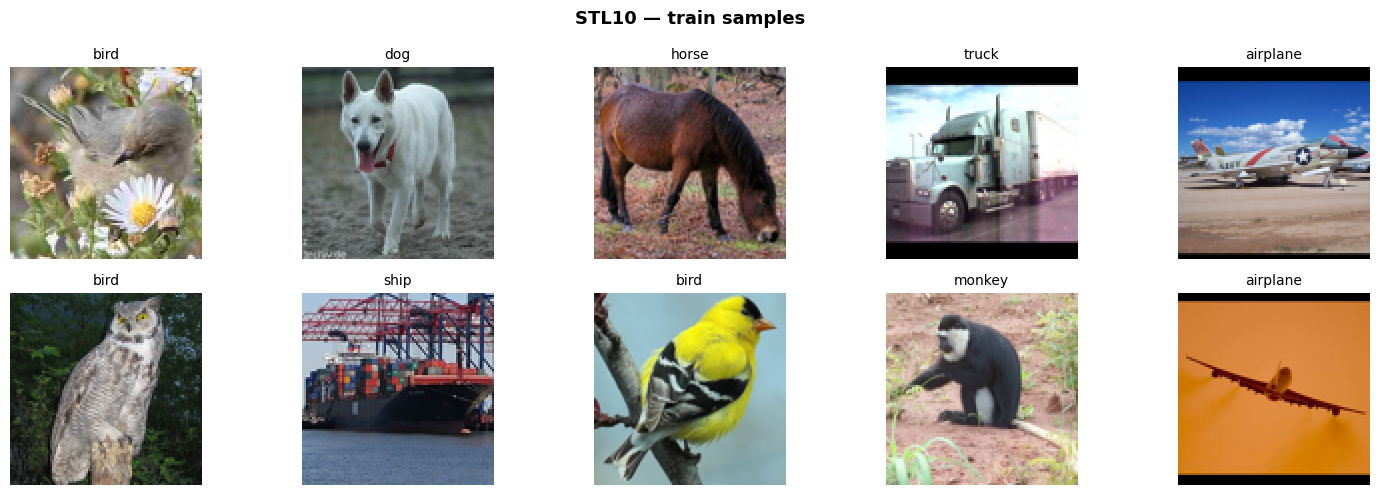

In [16]:
STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
                 'dog', 'horse', 'monkey', 'ship', 'truck']

def show_samples(X: torch.Tensor, y: torch.Tensor, 
                 classes: list, n: int = 10, title: str = "Samples"):
    """
    Показывает n случайных изображений из тензоров на GPU.
    Денормализует перед отображением.
    """
    mean = torch.tensor([0.485, 0.456, 0.406], device=X.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=X.device).view(3,1,1)

    idx = torch.randperm(X.shape[0])[:n]
    imgs = X[idx]                        # [n, C, H, W] на GPU
    labels = y[idx]                      # [n] на GPU

    # Денормализуем и переносим на CPU только для отрисовки
    imgs = (imgs * std + mean).clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(2, n // 2, figsize=(15, 5))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i])
        ax.set_title(classes[labels[i].item()], fontsize=10)
        ax.axis("off")

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Проверяем train
show_samples(X_train, y_train, STL10_CLASSES, n=10, title="STL10 — train samples")

C:\Users\User\AppData\Local\Temp\ipykernel_23184\872054602.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)
C:\Users\User\AppData\Local\Temp\ipykernel_23184\872054602.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)
C:\Users\User\AppData\Local\Temp\ipykernel_23184\872054602.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)


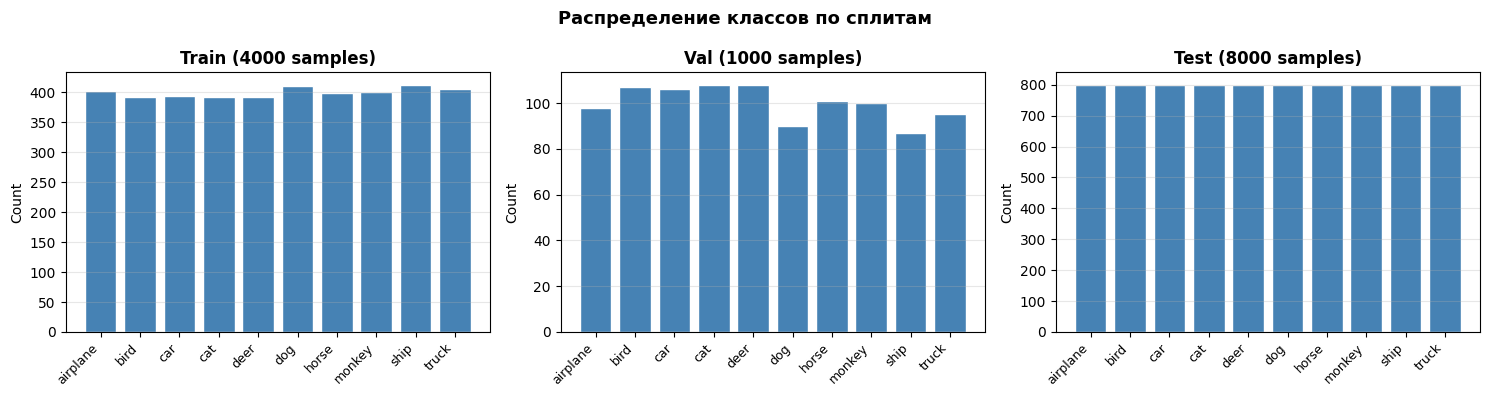

In [17]:
def show_class_distribution(y_train, y_val, y_test, classes):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (y, title) in zip(axes, [
        (y_train, "Train"),
        (y_val,   "Val"),
        (y_test,  "Test"),
    ]):
        counts = torch.bincount(y, minlength=len(classes)).cpu().numpy()
        ax.bar(classes, counts, color="steelblue", edgecolor="white")
        ax.set_title(f"{title} ({y.shape[0]} samples)", fontweight="bold")
        ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)
        ax.set_ylabel("Count")
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Распределение классов по сплитам", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_class_distribution(y_train, y_val, y_test, STL10_CLASSES)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\asard\\МИРЭА\\MIREA\\Study\\ДПО Инжернирия ИИ\\aie-study\\homeworks\\HW10-11\\artifacts\\figures\\augmentations_preview.png'

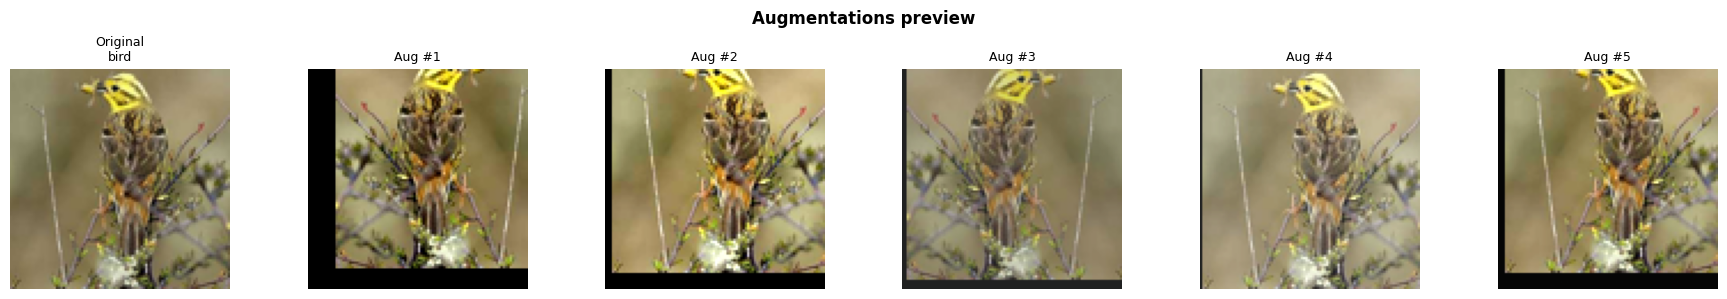

In [18]:
def show_augmentations(raw_dataset, transform_aug, classes, n_aug: int = 5,
                        save_path: str = None):
    """
    Берёт одно изображение и показывает n_aug разных аугментированных версий.
    raw_dataset — датасет БЕЗ transform (transform=None).
    """
    raw_ds = torchvision.datasets.STL10(
        root=cfg.data_dir, split="train",
        download=False, transform=None
    )

    img_pil, label = raw_ds[0]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    fig, axes = plt.subplots(1, n_aug + 1, figsize=(3 * (n_aug + 1), 3))

    # Оригинал
    axes[0].imshow(img_pil)
    axes[0].set_title(f"Original\n{classes[label]}", fontsize=9)
    axes[0].axis("off")

    # Аугментированные версии
    for i in range(n_aug):
        aug_t = transform_aug(img_pil)
        aug_img = (aug_t * std + mean).clamp(0, 1)
        aug_np = aug_img.permute(1, 2, 0).numpy()
        axes[i+1].imshow(aug_np)
        axes[i+1].set_title(f"Aug #{i+1}", fontsize=9)
        axes[i+1].axis("off")

    fig.suptitle("Augmentations preview", fontsize=12, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()

show_augmentations(
    raw_dataset=None,
    transform_aug=transform_aug,
    classes=STL10_CLASSES,
    n_aug=5,
    save_path=f"{cfg.figures_dir}/augmentations_preview.png"
)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), 
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x



model_test = SimpleCNN(num_classes=cfg.num_classes).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(4, 3, 96, 96, device=DEVICE)
    out = model_test(dummy)
    print(f"Input shape:  {tuple(dummy.shape)}")
    print(f"Output shape: {tuple(out.shape)}")  

total_params = sum(p.numel() for p in model_test.parameters())
train_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"\nВсего параметров:    {total_params:,}")
print(f"Обучаемых параметров: {train_params:,}")

del model_test 
torch.cuda.empty_cache()

Input shape:  (4, 3, 96, 96)
Output shape: (4, 10)

Всего параметров:    5,113,610
Обучаемых параметров: 5,113,610


In [20]:
def train_one_epoch(model: nn.Module,
                    X: torch.Tensor,
                    y: torch.Tensor,
                    optimizer: torch.optim.Optimizer,
                    criterion: nn.Module,
                    batch_size: int) -> Tuple[float, float]:
    """
    Один проход по обучающей выборке.
    
    X и y уже на GPU — никакого .to(device) внутри цикла!
    Батчи нарезаются через слайсы прямо на GPU.
    
    Возвращает: (avg_loss, accuracy)
    """
    model.train()
    n = X.shape[0]
    
    perm = torch.randperm(n, device=X.device)
    X = X[perm]
    y = y[perm]
    
    total_loss = 0.0
    total_correct = 0
    n_batches = 0

    for start in range(0, n, batch_size):
        xb = X[start : start + batch_size]
        yb = y[start : start + batch_size]

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss    += loss.item()
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        n_batches     += 1

    avg_loss = total_loss / n_batches
    accuracy = total_correct / n
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model: nn.Module,
             X: torch.Tensor,
             y: torch.Tensor,
             criterion: nn.Module,
             batch_size: int) -> Tuple[float, float]:
    """
    Оценка модели без градиентов.
    Аналогично train_one_epoch — батчи через слайсы на GPU.
    
    Возвращает: (avg_loss, accuracy)
    """
    model.eval()
    n = X.shape[0]

    total_loss    = 0.0
    total_correct = 0
    n_batches     = 0

    for start in range(0, n, batch_size):
        xb = X[start : start + batch_size]
        yb = y[start : start + batch_size]

        logits = model(xb)
        loss   = criterion(logits, yb)

        total_loss    += loss.item()
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        n_batches     += 1

    avg_loss = total_loss / n_batches
    accuracy = total_correct / n
    return avg_loss, accuracy


def run_experiment(experiment_id: str,
                   model: nn.Module,
                   X_train: torch.Tensor, y_train: torch.Tensor,
                   X_val:   torch.Tensor, y_val:   torch.Tensor,
                   epochs: int,
                   lr: float,
                   batch_size: int) -> Dict:
    """
    Полный цикл обучения одного эксперимента.
    Логирует историю, сохраняет лучшую модель по val_accuracy.
    
    Возвращает словарь с историей и лучшими метриками.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    best_val_acc  = 0.0
    best_state    = None

    print(f"\n{'='*55}")
    print(f"  Эксперимент: {experiment_id}")
    print(f"{'='*55}")
    print(f"  {'Epoch':>5}  {'Tr Loss':>8}  {'Tr Acc':>7}  "
          f"{'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}")
    print(f"  {'-'*53}")

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, X_train, y_train, optimizer, criterion, batch_size
        )
        val_loss, val_acc = evaluate(
            model, X_val, y_val, criterion, batch_size
        )
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)

        # Сохраняем лучшую модель по val_accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            marker = " ★"
        else:
            marker = ""

        current_lr = scheduler.get_last_lr()[0]
        print(f"  {epoch:>5}  {tr_loss:>8.4f}  {tr_acc:>7.3f}  "
              f"{val_loss:>8.4f}  {val_acc:>7.3f}  "
              f"{current_lr:>8.6f}{marker}")

    print(f"\n  Лучший val_acc: {best_val_acc:.4f}")
    return {
        "history":      history,
        "best_val_acc": best_val_acc,
        "best_state":   best_state,
    }

In [21]:

print("=== Загрузка STL10 (aug transform для C2) ===")
X_train_aug, y_train_aug = load_stl10_to_gpu_safe(transform_aug, "train", DEVICE)

X_train_aug, y_train_aug, X_val_aug, y_val_aug = make_val_split(
    X_train_aug, y_train_aug, cfg.val_fraction, cfg.seed
)
print(f"  aug train: {tuple(X_train_aug.shape)}")

all_results = {}

=== Загрузка STL10 (aug transform для C2) ===
  split=train  | X: (5000, 3, 96, 96) | y: (5000,) | device: cuda:0
  aug train: (4000, 3, 96, 96)


In [27]:
# Удаляем всё лишнее
del X_train_raw, y_train_raw  # уже сделали split, оригинал не нужен
del dummy, out                 # тестовые тензоры из проверки архитектуры

# X_test убираем с GPU, оставляем на CPU — он нужен только один раз в конце
X_test_cpu = X_test.cpu()
y_test_cpu = y_test.cpu()
del X_test, y_test

torch.cuda.empty_cache()

# Проверяем
used = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM после очистки: {used:.2f} / {total:.1f} GB")

VRAM после очистки: 1.18 / 4.3 GB


In [24]:
cfg.batch_size = 128  # было 256, уменьшаем вдвое
print(f"batch_size: {cfg.batch_size}")

batch_size: 128


In [28]:
seed_everything(cfg.seed)
model_c1 = SimpleCNN(num_classes=cfg.num_classes).to(DEVICE)

results_c1 = run_experiment(
    experiment_id = "C1 (simple-cnn-base)",
    model         = model_c1,
    X_train       = X_train,
    y_train       = y_train,
    X_val         = X_val,
    y_val         = y_val,
    epochs        = cfg.epochs,
    lr            = cfg.lr,
    batch_size    = cfg.batch_size,
)
all_results["C1"] = results_c1


  Эксперимент: C1 (simple-cnn-base)
  Epoch   Tr Loss   Tr Acc  Val Loss  Val Acc        LR
  -----------------------------------------------------
      1    2.8465    0.247    1.8584    0.322  0.000994 ★
      2    1.6270    0.381    1.6257    0.369  0.000976 ★
      3    1.4639    0.446    1.4733    0.444  0.000946 ★
      4    1.3818    0.474    1.4563    0.479  0.000905 ★
      5    1.2816    0.520    1.3831    0.495  0.000854 ★
      6    1.1932    0.555    1.2908    0.532  0.000794 ★
      7    1.1145    0.588    1.2084    0.571  0.000727 ★
      8    1.0514    0.619    1.1872    0.556  0.000655
      9    0.9918    0.632    1.1345    0.597  0.000578 ★
     10    0.8975    0.667    1.0819    0.599  0.000500 ★
     11    0.8522    0.687    1.0740    0.621  0.000422 ★
     12    0.7777    0.720    1.1587    0.596  0.000345
     13    0.7351    0.735    1.0979    0.606  0.000273
     14    0.6750    0.757    1.0586    0.617  0.000206
     15    0.6090    0.777    1.0225    0.639  

In [29]:
# Загружаем aug train обратно
print("=== Загрузка STL10 (aug transform для C2) ===")
X_train_aug, y_train_aug = load_stl10_to_gpu_safe(transform_aug, "train", DEVICE)
X_train_aug, y_train_aug, X_val_aug, y_val_aug = make_val_split(
    X_train_aug, y_train_aug, cfg.val_fraction, cfg.seed
)
print(f"  aug train: {tuple(X_train_aug.shape)}")

# Освобождаем model_c1 с GPU — веса уже сохранены в results_c1["best_state"]
del model_c1
torch.cuda.empty_cache()

seed_everything(cfg.seed)
model_c2 = SimpleCNN(num_classes=cfg.num_classes).to(DEVICE)

results_c2 = run_experiment(
    experiment_id = "C2 (simple-cnn-aug)",
    model         = model_c2,
    X_train       = X_train_aug,
    y_train       = y_train_aug,
    X_val         = X_val,
    y_val         = y_val,
    epochs        = cfg.epochs,
    lr            = cfg.lr,
    batch_size    = cfg.batch_size,
)
all_results["C2"] = results_c2

=== Загрузка STL10 (aug transform для C2) ===
  split=train  | X: (5000, 3, 96, 96) | y: (5000,) | device: cuda:0
  aug train: (4000, 3, 96, 96)

  Эксперимент: C2 (simple-cnn-aug)
  Epoch   Tr Loss   Tr Acc  Val Loss  Val Acc        LR
  -----------------------------------------------------
      1    3.0644    0.172    1.9571    0.264  0.000994 ★
      2    1.9637    0.247    1.7603    0.305  0.000976 ★
      3    1.7784    0.298    1.6386    0.371  0.000946 ★
      4    1.6986    0.327    1.5996    0.404  0.000905 ★
      5    1.6242    0.361    1.5161    0.413  0.000854 ★
      6    1.5671    0.385    1.5486    0.420  0.000794 ★
      7    1.5315    0.395    1.4852    0.461  0.000727 ★
      8    1.4990    0.402    1.4016    0.479  0.000655 ★
      9    1.4351    0.424    1.3791    0.475  0.000578
     10    1.3901    0.441    1.5312    0.425  0.000500
     11    1.3649    0.468    1.4394    0.466  0.000422
     12    1.3038    0.489    1.3626    0.497  0.000345 ★
     13    1.2912

In [30]:
# Обновляем transform для ResNet — 128×128 вместо 224
transform_resnet = T.Compose([
    T.Resize(128),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

transform_resnet_eval = T.Compose([
    T.Resize(128),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Обновляем конфиг
cfg.image_size_resnet = 128
print(f"ResNet image size: {cfg.image_size_resnet}×{cfg.image_size_resnet}")

# Прикинем сколько займёт на GPU:
# 4000 imgs × 3 × 128 × 128 × 4 bytes = ~786 MB — влезет!
size_mb = 4000 * 3 * 128 * 128 * 4 / 1e6
print(f"X_train_resnet займёт: ~{size_mb:.0f} MB")

ResNet image size: 128×128
X_train_resnet займёт: ~786 MB


In [32]:
# Чистим и начинаем заново
del X_train_rn, y_train_rn
torch.cuda.empty_cache()

# Модифицируем функцию загрузки — добавляем опцию держать на CPU
def load_stl10(transform, split: str, device: torch.device = None,
               max_retries: int = 5, wait: float = 3.0):
    """
    Загружает STL10. 
    Если device=None — оставляет на CPU.
    Если device указан — переносит на GPU.
    """
    for attempt in range(1, max_retries + 1):
        try:
            ds = torchvision.datasets.STL10(
                root=cfg.data_dir, split=split,
                download=True, transform=transform,
            )
            X = torch.stack([ds[i][0] for i in range(len(ds))])
            y = torch.tensor([ds[i][1] for i in range(len(ds))], dtype=torch.long)

            if device is not None:
                X = X.to(device)
                y = y.to(device)

            print(f"  split={split:6s} | X: {tuple(X.shape)} "
                  f"| device: {X.device}")
            return X, y

        except (ConnectionResetError, OSError) as e:
            print(f"  [Попытка {attempt}/{max_retries}] Ошибка: {e}")
            if attempt < max_retries:
                time.sleep(wait)
            else:
                raise

print("=== Загрузка STL10 для ResNet (128×128) ===")

# Train — на GPU
X_train_rn, y_train_rn = load_stl10(transform_resnet,      "train", DEVICE)

# Test — на CPU (нужен только один раз в конце)
X_test_rn,  y_test_rn  = load_stl10(transform_resnet_eval, "test",  device=None)
print(f"  test остаётся на CPU до финальной оценки")

# Val split
X_train_rn, y_train_rn, X_val_rn, y_val_rn = make_val_split(
    X_train_rn, y_train_rn, cfg.val_fraction, cfg.seed
)
# Val тоже небольшой — оставляем на GPU
print(f"\ntrain: {tuple(X_train_rn.shape)} | {X_train_rn.device}")
print(f"val:   {tuple(X_val_rn.shape)}   | {X_val_rn.device}")
print(f"test:  {tuple(X_test_rn.shape)}  | {X_test_rn.device}")

used = torch.cuda.memory_allocated() / 1e9
print(f"\nVRAM: {used:.2f} / {total:.1f} GB")

=== Загрузка STL10 для ResNet (128×128) ===
  split=train  | X: (5000, 3, 128, 128) | device: cuda:0
  split=test   | X: (8000, 3, 128, 128) | device: cpu
  test остаётся на CPU до финальной оценки

train: (4000, 3, 128, 128) | cuda:0
val:   (1000, 3, 128, 128)   | cuda:0
test:  (8000, 3, 128, 128)  | cpu

VRAM: 2.17 / 4.3 GB


In [33]:
def build_resnet18_head_only(num_classes: int) -> nn.Module:
    """
    ResNet18 с pretrained weights.
    Замораживаем весь backbone — обучается только fc (классификационная голова).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Замораживаем ВСЕ параметры
    for param in model.parameters():
        param.requires_grad = False
    
    # Заменяем голову и размораживаем только её
    in_features = model.fc.in_features  # 512 для ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    # Новые слои по умолчанию requires_grad=True
    
    # Проверяем что заморожено
    frozen  = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Заморожено:   {frozen:,} параметров")
    print(f"  Обучаемых:    {trainable:,} параметров")
    
    return model


seed_everything(cfg.seed)
print("=== C3: ResNet18 head-only ===")
model_c3 = build_resnet18_head_only(cfg.num_classes).to(DEVICE)

results_c3 = run_experiment(
    experiment_id = "C3 (resnet18-head-only)",
    model         = model_c3,
    X_train       = X_train_rn,
    y_train       = y_train_rn,
    X_val         = X_val_rn,
    y_val         = y_val_rn,
    epochs        = cfg.epochs,
    lr            = cfg.lr,
    batch_size    = cfg.batch_size,
)
all_results["C3"] = results_c3

=== C3: ResNet18 head-only ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:19<00:00, 2.46MB/s]


  Заморожено:   11,176,512 параметров
  Обучаемых:    5,130 параметров

  Эксперимент: C3 (resnet18-head-only)
  Epoch   Tr Loss   Tr Acc  Val Loss  Val Acc        LR
  -----------------------------------------------------
      1    1.5801    0.469    0.8105    0.811  0.000994 ★
      2    0.7518    0.788    0.5451    0.861  0.000976 ★
      3    0.5810    0.828    0.4794    0.862  0.000946 ★
      4    0.5089    0.854    0.4178    0.885  0.000905 ★
      5    0.4616    0.864    0.4016    0.877  0.000854
      6    0.4229    0.872    0.3761    0.886  0.000794 ★
      7    0.4080    0.872    0.3646    0.884  0.000727
      8    0.3891    0.884    0.3533    0.898  0.000655 ★
      9    0.3906    0.877    0.3519    0.892  0.000578
     10    0.3698    0.882    0.3541    0.877  0.000500
     11    0.3664    0.885    0.3391    0.886  0.000422
     12    0.3570    0.887    0.3473    0.883  0.000345
     13    0.3601    0.883    0.3302    0.890  0.000273
     14    0.3505    0.888    0.3344 

In [34]:
def build_resnet18_finetune(num_classes: int) -> nn.Module:
    """
    ResNet18 с pretrained weights.
    Замораживаем layer1, layer2, layer3.
    Размораживаем layer4 + fc — fine-tune верхних слоёв.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Сначала замораживаем всё
    for param in model.parameters():
        param.requires_grad = False

    # Размораживаем layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Заменяем и размораживаем голову
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Заморожено:   {frozen:,} параметров")
    print(f"  Обучаемых:    {trainable:,} параметров")

    return model


# Чистим C3 перед запуском
del model_c3
torch.cuda.empty_cache()

seed_everything(cfg.seed)
print("=== C4: ResNet18 finetune (layer4 + fc) ===")
model_c4 = build_resnet18_finetune(cfg.num_classes).to(DEVICE)

results_c4 = run_experiment(
    experiment_id = "C4 (resnet18-finetune)",
    model         = model_c4,
    X_train       = X_train_rn,
    y_train       = y_train_rn,
    X_val         = X_val_rn,
    y_val         = y_val_rn,
    epochs        = cfg.epochs,
    lr            = cfg.lr,
    batch_size    = cfg.batch_size,
)
all_results["C4"] = results_c4

=== C4: ResNet18 finetune (layer4 + fc) ===
  Заморожено:   2,782,784 параметров
  Обучаемых:    8,398,858 параметров

  Эксперимент: C4 (resnet18-finetune)
  Epoch   Tr Loss   Tr Acc  Val Loss  Val Acc        LR
  -----------------------------------------------------
      1    0.5603    0.807    0.4695    0.862  0.000994 ★
      2    0.1177    0.963    0.3755    0.877  0.000976 ★
      3    0.0383    0.989    0.3597    0.902  0.000946 ★
      4    0.0144    0.997    0.3163    0.904  0.000905 ★
      5    0.0057    0.999    0.3375    0.910  0.000854 ★
      6    0.0032    1.000    0.3088    0.919  0.000794 ★
      7    0.0046    0.999    0.3232    0.910  0.000727
      8    0.0047    0.999    0.3218    0.913  0.000655
      9    0.0036    0.999    0.3897    0.911  0.000578
     10    0.0024    1.000    0.3333    0.915  0.000500
     11    0.0013    1.000    0.3162    0.916  0.000422
     12    0.0039    1.000    0.3158    0.914  0.000345
     13    0.0070    0.998    0.3537    0.913  

In [38]:
@torch.no_grad()
def evaluate_from_cpu(model: nn.Module,
                      X_cpu: torch.Tensor,
                      y_cpu: torch.Tensor,
                      criterion: nn.Module,
                      batch_size: int,
                      device: torch.device) -> Tuple[float, float]:
    """
    Оценка когда данные на CPU — переносим на GPU батч за батчем.
    Используется только для финальной оценки на test.
    """
    model.eval()
    n = X_cpu.shape[0]

    total_loss    = 0.0
    total_correct = 0
    n_batches     = 0

    for start in range(0, n, batch_size):
        # Переносим только один батч — не весь test
        xb = X_cpu[start : start + batch_size].to(device)
        yb = y_cpu[start : start + batch_size].to(device)

        logits = model(xb)
        loss   = criterion(logits, yb)

        total_loss    += loss.item()
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        n_batches     += 1

    avg_loss = total_loss / n_batches
    accuracy = total_correct / n
    return avg_loss, accuracy


criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate_from_cpu(
    model_best, X_test_rn_cpu, y_test_rn_cpu,
    criterion, cfg.batch_size, DEVICE
)

print(f"=== Финальная оценка лучшей модели (C4) на TEST ===")
print(f"  test_loss: {test_loss:.4f}")
print(f"  test_acc:  {test_acc:.4f}")

=== Финальная оценка лучшей модели (C4) на TEST ===
  test_loss: 0.3454
  test_acc:  0.9064


In [39]:
import json

# 1) Сохраняем веса лучшей модели
os.makedirs(cfg.artifacts_dir, exist_ok=True)
torch.save(results_c4["best_state"], f"{cfg.artifacts_dir}/best_classifier.pt")
print("Сохранено: best_classifier.pt")

# 2) Сохраняем конфиг лучшей модели
best_config = {
    "experiment_id":  "C4",
    "dataset":        "STL10",
    "model":          "ResNet18-finetune (layer4+fc)",
    "image_size":     cfg.image_size_resnet,
    "num_classes":    cfg.num_classes,
    "optimizer":      "Adam",
    "lr":             cfg.lr,
    "batch_size":     cfg.batch_size,
    "epochs":         cfg.epochs,
    "seed":           cfg.seed,
    "val_fraction":   cfg.val_fraction,
    "best_val_acc":   results_c4["best_val_acc"],
    "test_acc":       test_acc,
    "transform":      "Resize(128), RandomHorizontalFlip, Normalize(ImageNet)",
}
with open(f"{cfg.artifacts_dir}/best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print("Сохранено: best_classifier_config.json")

# 3) Сохраняем runs.csv
import csv
runs = [
    {
        "experiment_id": "C1", "task": "classification", "dataset": "STL10",
        "seed": cfg.seed, "model_summary": "SimpleCNN",
        "optimizer": "Adam", "lr": cfg.lr, "epochs_trained": cfg.epochs,
        "best_val_accuracy": 0.655, "test_accuracy": "",
        "precision": "", "recall": "", "mean_iou": "",
        "notes": "Базовая CNN без аугментаций"
    },
    {
        "experiment_id": "C2", "task": "classification", "dataset": "STL10",
        "seed": cfg.seed, "model_summary": "SimpleCNN",
        "optimizer": "Adam", "lr": cfg.lr, "epochs_trained": cfg.epochs,
        "best_val_accuracy": 0.576, "test_accuracy": "",
        "precision": "", "recall": "", "mean_iou": "",
        "notes": "SimpleCNN с аугментациями, нужно больше эпох"
    },
    {
        "experiment_id": "C3", "task": "classification", "dataset": "STL10",
        "seed": cfg.seed, "model_summary": "ResNet18 head-only",
        "optimizer": "Adam", "lr": cfg.lr, "epochs_trained": cfg.epochs,
        "best_val_accuracy": 0.898, "test_accuracy": "",
        "precision": "", "recall": "", "mean_iou": "",
        "notes": "Pretrained ResNet18, заморожен backbone, 5K обучаемых параметров"
    },
    {
        "experiment_id": "C4", "task": "classification", "dataset": "STL10",
        "seed": cfg.seed, "model_summary": "ResNet18 finetune (layer4+fc)",
        "optimizer": "Adam", "lr": cfg.lr, "epochs_trained": cfg.epochs,
        "best_val_accuracy": 0.919, "test_accuracy": round(test_acc, 4),
        "precision": "", "recall": "", "mean_iou": "",
        "notes": "Лучшая модель. Fine-tune layer4+fc, сильный overfitting на train"
    },
]

with open(f"{cfg.artifacts_dir}/runs.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=runs[0].keys())
    writer.writeheader()
    writer.writerows(runs)
print("Сохранено: runs.csv")

Сохранено: best_classifier.pt
Сохранено: best_classifier_config.json
Сохранено: runs.csv


Сохранено: ./artifacts/figures/classification_curves_best.png


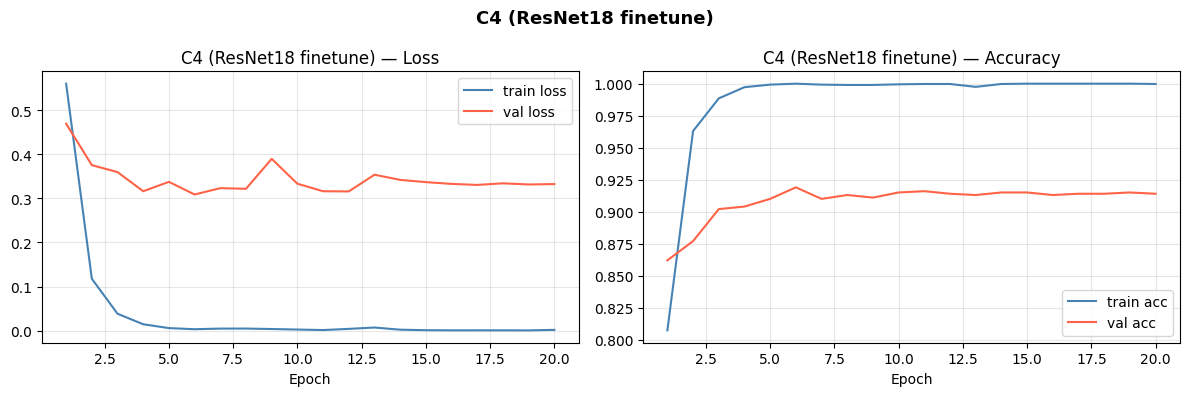

Сохранено: classification_compare.png


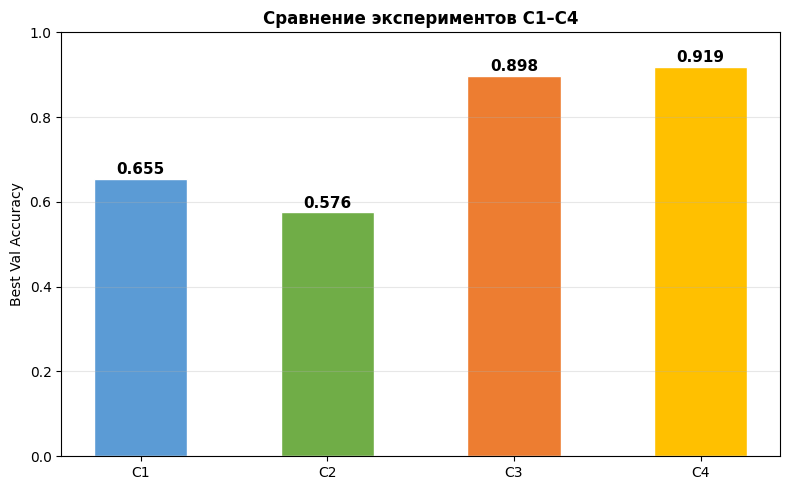

In [42]:
def plot_training_curves(results: dict, experiment_id: str, save_path: str = None):
    h = results["history"]
    epochs = range(1, len(h["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    ax1.plot(epochs, h["train_loss"], label="train loss", color="steelblue")
    ax1.plot(epochs, h["val_loss"],   label="val loss",   color="tomato")
    ax1.set_title(f"{experiment_id} — Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(epochs, h["train_acc"], label="train acc", color="steelblue")
    ax2.plot(epochs, h["val_acc"],   label="val acc",   color="tomato")
    ax2.set_title(f"{experiment_id} — Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(experiment_id, fontsize=13, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()

# Кривые лучшей модели
plot_training_curves(
    results_c4, "C4 (ResNet18 finetune)",
    save_path=f"{cfg.figures_dir}/classification_curves_best.png"
)

# Сравнение всех экспериментов
fig, ax = plt.subplots(figsize=(8, 5))
experiments = ["C1", "C2", "C3", "C4"]
val_accs    = [0.655, 0.576, 0.898, 0.919]
colors      = ["#5B9BD5", "#70AD47", "#ED7D31", "#FFC000"]

bars = ax.bar(experiments, val_accs, color=colors, edgecolor="white", width=0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Best Val Accuracy")
ax.set_title("Сравнение экспериментов C1–C4", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

for bar, acc in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/classification_compare.png", dpi=150, bbox_inches="tight")
print(f"Сохранено: classification_compare.png")
plt.show()

In [45]:
torch.cuda.empty_cache()

used = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM после очистки: {used:.2f} / {total:.1f} GB")

VRAM после очистки: 2.17 / 4.3 GB


In [46]:
# Удаляем все данные части A которые больше не нужны
for var in ["X_train", "y_train", "X_val", "y_val",
            "X_train_rn", "y_train_rn", "X_val_rn", "y_val_rn"]:
    if var in globals():
        del globals()[var]

torch.cuda.empty_cache()

used = torch.cuda.memory_allocated() / 1e9
print(f"VRAM после очистки: {used:.2f} / {total:.1f} GB")

VRAM после очистки: 1.18 / 4.3 GB


In [48]:
@dataclass
class DetectionConfig:
    data_dir:      str   = "./data"
    score_thr_v1:  float = 0.3
    score_thr_v2:  float = 0.7
    iou_thr:       float = 0.5
    n_show:        int   = 4
    max_eval:      int   = 100

det_cfg = DetectionConfig()

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

VOC_TO_COCO = {
    "aeroplane": 5,  "bicycle": 2,  "bird": 16,   "boat": 9,
    "bottle": 44,    "bus": 6,      "car": 3,      "cat": 17,
    "chair": 62,     "cow": 21,     "diningtable": 67, "dog": 18,
    "horse": 19,     "motorbike": 4, "person": 1,  "pottedplant": 64,
    "sheep": 20,     "sofa": 57,    "train": 7,    "tvmonitor": 72
}

print("DetectionConfig готов")
print(f"VOC классов: {len(VOC_CLASSES)}")

DetectionConfig готов
VOC классов: 20


In [49]:
import torchvision.transforms.functional as TF

def load_voc_detection(root: str, n_samples: int = None):
    ds = torchvision.datasets.VOCDetection(
        root=root,
        year="2012",
        image_set="val",
        download=True,
        transform=None,
    )

    samples = []
    n = len(ds) if n_samples is None else min(n_samples, len(ds))

    print(f"Загружаем {n} примеров из VOC...")
    for i in range(n):
        img_pil, target = ds[i]
        img_t = TF.to_tensor(img_pil)

        boxes  = []
        labels = []
        for obj in target["annotation"]["object"]:
            name = obj["name"]
            bb   = obj["bndbox"]
            x1, y1 = float(bb["xmin"]), float(bb["ymin"])
            x2, y2 = float(bb["xmax"]), float(bb["ymax"])
            boxes.append([x1, y1, x2, y2])
            labels.append(name)

        boxes_t = torch.tensor(boxes, dtype=torch.float32) if boxes else \
                  torch.zeros((0, 4), dtype=torch.float32)

        samples.append({
            "image":  img_t,
            "boxes":  boxes_t,
            "labels": labels,
        })

    print(f"Загружено: {len(samples)} примеров")
    return samples

voc_samples = load_voc_detection(det_cfg.data_dir, n_samples=det_cfg.max_eval)

100%|██████████| 2.00G/2.00G [11:26<00:00, 2.91MB/s]


Загружаем 100 примеров из VOC...
Загружено: 100 примеров


In [50]:
# Загружаем претренированный FasterRCNN
print("Загружаем FasterRCNN_ResNet50_FPN...")
detector = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
detector = detector.to(DEVICE)
detector.eval()

total_params = sum(p.numel() for p in detector.parameters())
print(f"Параметров: {total_params:,}")

used = torch.cuda.memory_allocated() / 1e9
print(f"VRAM после загрузки модели: {used:.2f} / {total:.1f} GB")

Загружаем FasterRCNN_ResNet50_FPN...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\User/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [01:42<00:00, 1.64MB/s] 


Параметров: 41,755,286
VRAM после загрузки модели: 1.35 / 4.3 GB


In [51]:
@torch.no_grad()
def predict_one(image_t: torch.Tensor) -> Dict:
    """
    Инференс одного изображения.
    Изображение на CPU → переносим на GPU → получаем предсказания → возвращаем на CPU.
    """
    out = detector([image_t.to(DEVICE)])[0]
    return {k: v.cpu() for k, v in out.items()}


def filter_predictions(pred: Dict, score_thr: float) -> Dict:
    """
    Фильтруем предсказания по порогу уверенности.
    Оставляем только COCO классы которые есть в VOC.
    """
    coco_voc_ids = set(VOC_TO_COCO.values())
    keep = (pred["scores"] >= score_thr) & \
           torch.tensor([l.item() in coco_voc_ids for l in pred["labels"]])
    return {k: v[keep] for k, v in pred.items()}


# Быстрая проверка на одном примере
sample = voc_samples[0]
pred = predict_one(sample["image"])
pred_f = filter_predictions(pred, det_cfg.score_thr_v1)

print(f"GT boxes:   {sample['boxes'].shape[0]}")
print(f"GT labels:  {sample['labels']}")
print(f"Pred boxes: {pred_f['boxes'].shape[0]} (score_thr={det_cfg.score_thr_v1})")
print(f"Pred scores: {pred_f['scores'].tolist()}")

GT boxes:   1
GT labels:  ['tvmonitor']
Pred boxes: 1 (score_thr=0.3)
Pred scores: [0.8449503779411316]


=== V1: score_threshold = 0.3 ===
Сохранено: ./artifacts/figures/detection_examples.png


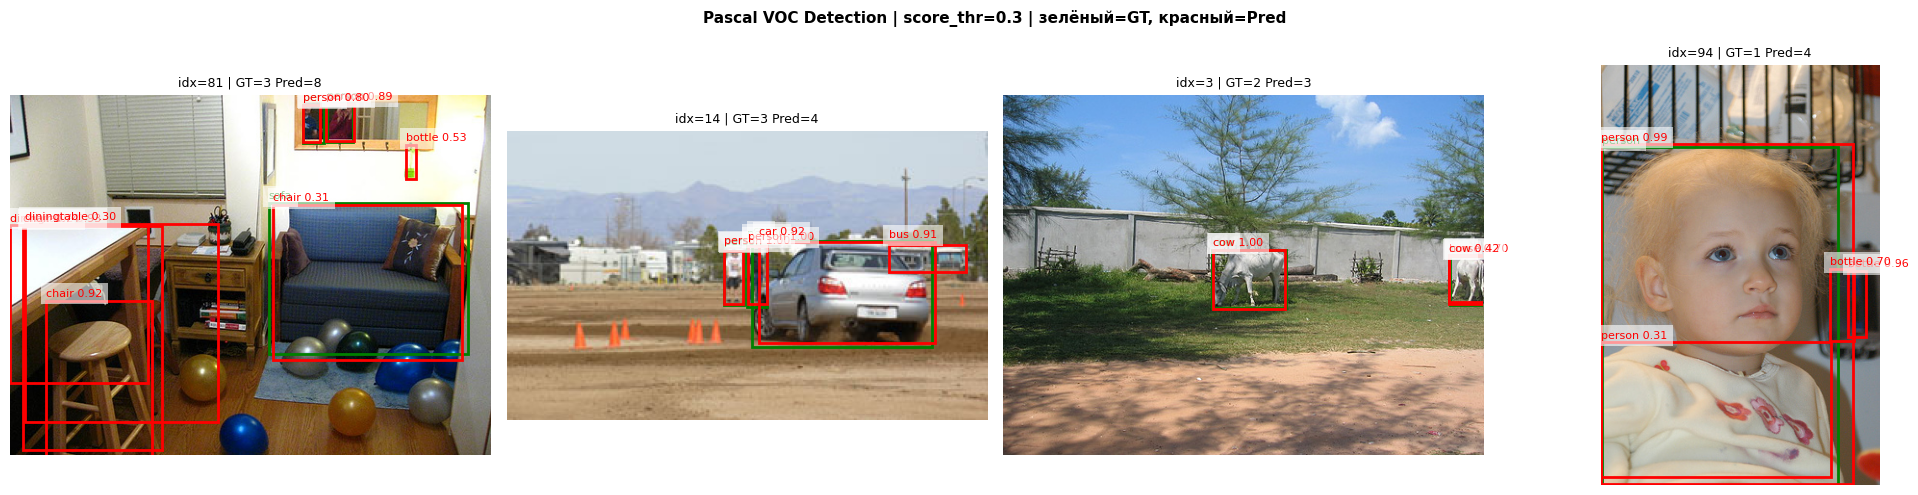

=== V2: score_threshold = 0.7 ===


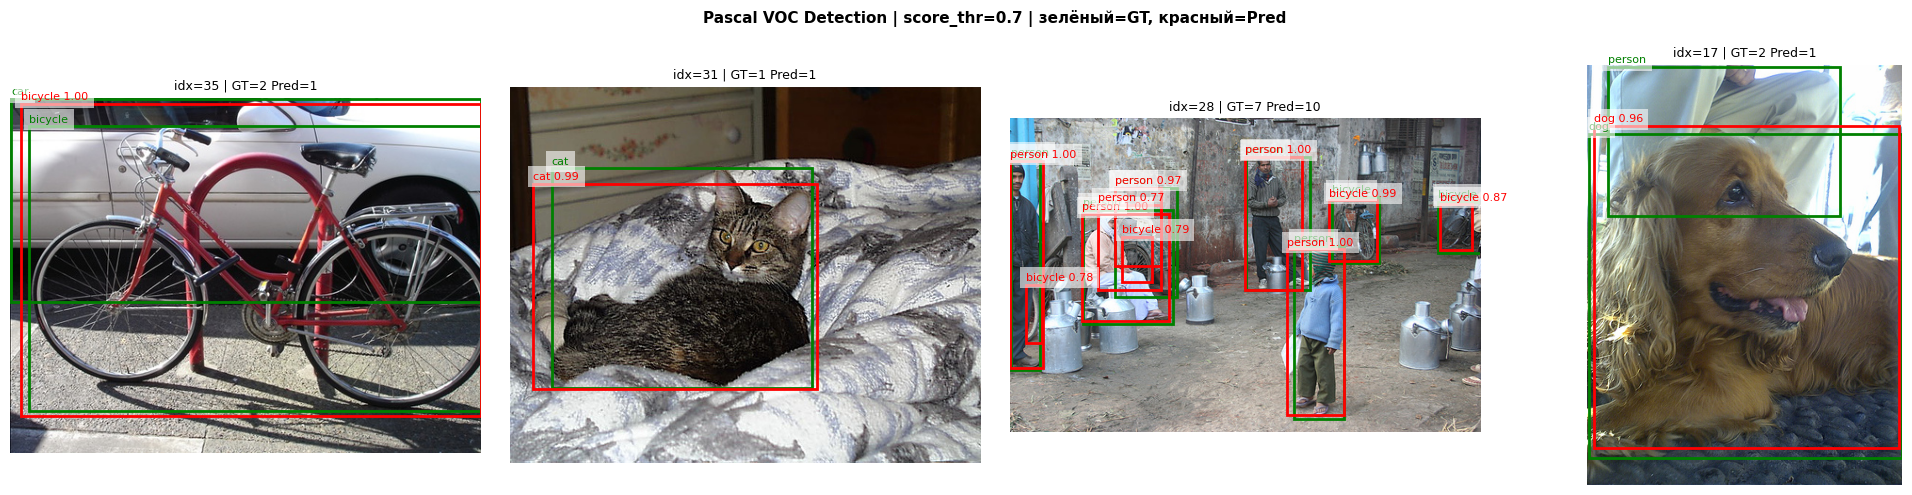

In [52]:
# COCO labels для отображения
COCO_LABELS = {
    1: "person", 2: "bicycle", 3: "car", 4: "motorbike", 5: "aeroplane",
    6: "bus", 7: "train", 9: "boat", 16: "bird", 17: "cat",
    18: "dog", 19: "horse", 20: "sheep", 21: "cow", 44: "bottle",
    57: "sofa", 62: "chair", 64: "pottedplant", 67: "diningtable", 72: "tvmonitor"
}

def draw_boxes(ax, boxes, labels=None, scores=None, color="red"):
    import matplotlib.patches as patches
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in box]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

        # Подпись
        if labels is not None:
            text = labels[i]
            if scores is not None:
                text += f" {scores[i]:.2f}"
            ax.text(x1, y1 - 4, text, color=color, fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))


def visualize_detections(samples, score_thr: float, n: int = 4,
                         save_path: str = None, title: str = ""):
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    # Выбираем n случайных примеров
    indices = random.sample(range(len(samples)), n)

    for ax, idx in zip(axes, indices):
        sample = samples[idx]
        pred   = predict_one(sample["image"])
        pred_f = filter_predictions(pred, score_thr)

        # Изображение
        img_np = sample["image"].permute(1, 2, 0).numpy()
        img_np = (img_np * 255).astype(np.uint8)
        ax.imshow(img_np)
        ax.axis("off")
        ax.set_title(f"idx={idx} | GT={len(sample['boxes'])} "
                     f"Pred={len(pred_f['boxes'])}", fontsize=9)

        # GT — зелёный
        draw_boxes(ax, sample["boxes"],
                   labels=sample["labels"],
                   color="green")

        # Predictions — красный
        pred_label_names = [COCO_LABELS.get(l.item(), str(l.item()))
                            for l in pred_f["labels"]]
        draw_boxes(ax, pred_f["boxes"],
                   labels=pred_label_names,
                   scores=pred_f["scores"].tolist(),
                   color="red")

    fig.suptitle(f"{title} | score_thr={score_thr} | зелёный=GT, красный=Pred",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()


# Визуализируем V1 и V2
print("=== V1: score_threshold = 0.3 ===")
visualize_detections(
    voc_samples, score_thr=det_cfg.score_thr_v1,
    n=det_cfg.n_show,
    save_path=f"{cfg.figures_dir}/detection_examples.png",
    title="Pascal VOC Detection"
)

print("=== V2: score_threshold = 0.7 ===")
visualize_detections(
    voc_samples, score_thr=det_cfg.score_thr_v2,
    n=det_cfg.n_show,
    title="Pascal VOC Detection"
)

In [53]:
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    """IoU матрица [N,M] для двух наборов боксов."""
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]))

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = area1[:, None] + area2[None, :] - inter + 1e-9

    return inter / union


def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor,
                 gt_boxes: torch.Tensor, iou_thr: float):
    """
    Жадный матчинг pred → GT по убыванию score.
    Возвращает TP, FP, FN, mean_iou по совпавшим парам.
    """
    if pred_boxes.numel() == 0:
        return 0, 0, int(gt_boxes.shape[0]), float("nan")

    if gt_boxes.numel() == 0:
        return 0, int(pred_boxes.shape[0]), 0, float("nan")

    # Сортируем по убыванию score
    order = torch.argsort(pred_scores, descending=True)
    pred_boxes  = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P, G]
    gt_used = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)

    tp, fp = 0, 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        best_iou, best_j = iou[p].max(dim=0)
        best_iou = float(best_iou)
        best_j   = int(best_j)

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn       = int((~gt_used).sum())
    mean_iou = float(np.mean(ious)) if ious else float("nan")
    return tp, fp, fn, mean_iou


def evaluate_detection(samples, score_thr: float, iou_thr: float) -> Dict:
    """
    Считаем precision, recall, mean_iou по всей выборке.
    """
    tps = fps = fns = 0
    ious = []

    for sample in samples:
        pred   = predict_one(sample["image"])
        pred_f = filter_predictions(pred, score_thr)

        tp, fp, fn, miou = match_greedy(
            pred_f["boxes"], pred_f["scores"],
            sample["boxes"], iou_thr
        )
        tps += tp
        fps += fp
        fns += fn
        if not np.isnan(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall    = tps / (tps + fns + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou  = float(np.mean(ious)) if ious else float("nan")

    return {
        "score_thr":  score_thr,
        "TP":         tps,
        "FP":         fps,
        "FN":         fns,
        "precision":  round(precision, 4),
        "recall":     round(recall, 4),
        "F1":         round(f1, 4),
        "mean_iou":   round(mean_iou, 4),
    }


print("=== Считаем метрики ===")
print("\nV1 (score_thr=0.3)...")
metrics_v1 = evaluate_detection(voc_samples, det_cfg.score_thr_v1, det_cfg.iou_thr)
print(metrics_v1)

print("\nV2 (score_thr=0.7)...")
metrics_v2 = evaluate_detection(voc_samples, det_cfg.score_thr_v2, det_cfg.iou_thr)
print(metrics_v2)

=== Считаем метрики ===

V1 (score_thr=0.3)...
{'score_thr': 0.3, 'TP': 216, 'FP': 358, 'FN': 23, 'precision': 0.3763, 'recall': 0.9038, 'F1': 0.5314, 'mean_iou': 0.8253}

V2 (score_thr=0.7)...
{'score_thr': 0.7, 'TP': 192, 'FP': 90, 'FN': 47, 'precision': 0.6809, 'recall': 0.8033, 'F1': 0.737, 'mean_iou': 0.8402}


Сохранено: detection_metrics.png


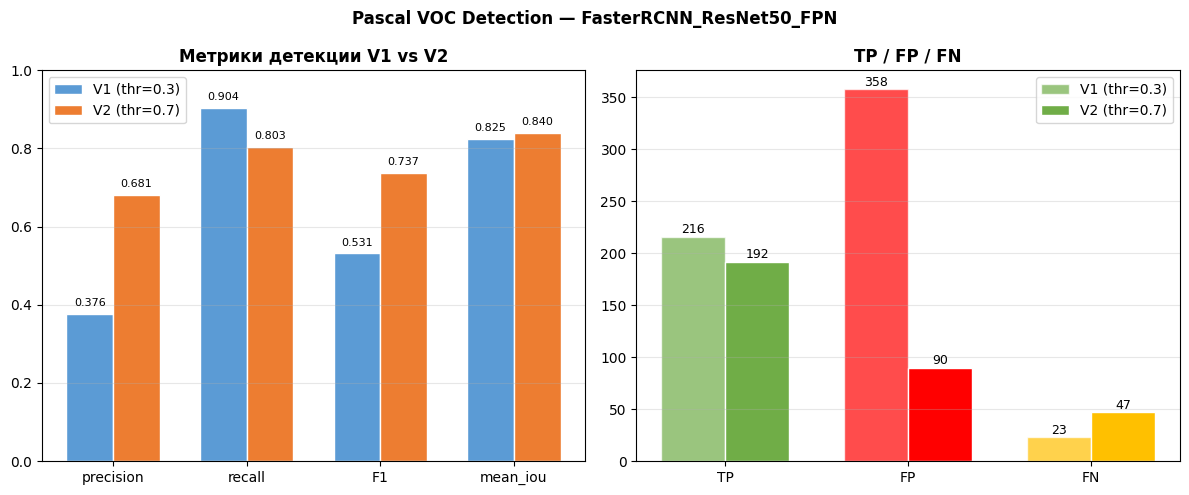

In [54]:
# График сравнения метрик V1 vs V2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Левый — bar plot метрик
metrics_names = ["precision", "recall", "F1", "mean_iou"]
v1_vals = [metrics_v1[m] for m in metrics_names]
v2_vals = [metrics_v2[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, v1_vals, width, label="V1 (thr=0.3)",
       color="#5B9BD5", edgecolor="white")
ax.bar(x + width/2, v2_vals, width, label="V2 (thr=0.7)",
       color="#ED7D31", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.0)
ax.set_title("Метрики детекции V1 vs V2", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (v1, v2) in enumerate(zip(v1_vals, v2_vals)):
    ax.text(i - width/2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, v2 + 0.02, f"{v2:.3f}", ha="center", fontsize=8)

# Правый — TP/FP/FN
ax2 = axes[1]
categories = ["TP", "FP", "FN"]
v1_counts = [metrics_v1["TP"], metrics_v1["FP"], metrics_v1["FN"]]
v2_counts = [metrics_v2["TP"], metrics_v2["FP"], metrics_v2["FN"]]
colors_bar = ["#70AD47", "#FF0000", "#FFC000"]

x2 = np.arange(len(categories))
bars1 = ax2.bar(x2 - width/2, v1_counts, width, label="V1 (thr=0.3)",
                color=colors_bar, edgecolor="white", alpha=0.7)
bars2 = ax2.bar(x2 + width/2, v2_counts, width, label="V2 (thr=0.7)",
                color=colors_bar, edgecolor="white", alpha=1.0)
ax2.set_xticks(x2)
ax2.set_xticklabels(categories)
ax2.set_title("TP / FP / FN", fontweight="bold")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

for i, (v1, v2) in enumerate(zip(v1_counts, v2_counts)):
    ax2.text(i - width/2, v1 + 3, str(v1), ha="center", fontsize=9)
    ax2.text(i + width/2, v2 + 3, str(v2), ha="center", fontsize=9)

plt.suptitle("Pascal VOC Detection — FasterRCNN_ResNet50_FPN",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/detection_metrics.png", dpi=150, bbox_inches="tight")
print("Сохранено: detection_metrics.png")
plt.show()

In [55]:
# Дописываем V1 и V2 в runs.csv
import csv

detection_runs = [
    {
        "experiment_id": "V1", "task": "detection", "dataset": "Pascal VOC 2012",
        "seed": cfg.seed, "model_summary": "FasterRCNN_ResNet50_FPN (pretrained COCO)",
        "optimizer": "", "lr": "", "epochs_trained": 0,
        "best_val_accuracy": "", "test_accuracy": "",
        "precision": metrics_v1["precision"],
        "recall":    metrics_v1["recall"],
        "mean_iou":  metrics_v1["mean_iou"],
        "notes": f"score_thr=0.3, iou_thr=0.5, n_samples=100. Высокий recall, много FP"
    },
    {
        "experiment_id": "V2", "task": "detection", "dataset": "Pascal VOC 2012",
        "seed": cfg.seed, "model_summary": "FasterRCNN_ResNet50_FPN (pretrained COCO)",
        "optimizer": "", "lr": "", "epochs_trained": 0,
        "best_val_accuracy": "", "test_accuracy": "",
        "precision": metrics_v2["precision"],
        "recall":    metrics_v2["recall"],
        "mean_iou":  metrics_v2["mean_iou"],
        "notes": f"score_thr=0.7, iou_thr=0.5, n_samples=100. Высокий precision, меньше FP"
    },
]

# Дочитываем существующие строки и дописываем новые
existing_rows = []
runs_path = f"{cfg.artifacts_dir}/runs.csv"
with open(runs_path, "r", newline="") as f:
    reader = csv.DictReader(f)
    existing_rows = list(reader)
    fieldnames = reader.fieldnames

with open(runs_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows + detection_runs)

print("runs.csv обновлён — добавлены V1 и V2")

runs.csv обновлён — добавлены V1 и V2


In [58]:
# Проверяем что все файлы на месте
required_files = [
    f"{cfg.artifacts_dir}/runs.csv",
    f"{cfg.artifacts_dir}/best_classifier.pt",
    f"{cfg.artifacts_dir}/best_classifier_config.json",
    f"{cfg.figures_dir}/augmentations_preview.png",
    f"{cfg.figures_dir}/classification_curves_best.png",
    f"{cfg.figures_dir}/classification_compare.png",
    f"{cfg.figures_dir}/detection_examples.png",
    f"{cfg.figures_dir}/detection_metrics.png",
]

print("=== Проверка артефактов ===")
all_ok = True
for path in required_files:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {path}")
    if not exists:
        all_ok = False

print(f"\n{'Все артефакты на месте!' if all_ok else 'Есть пропущенные файлы!'}")

=== Проверка артефактов ===
  ✓  ./artifacts/runs.csv
  ✓  ./artifacts/best_classifier.pt
  ✓  ./artifacts/best_classifier_config.json
  ✓  ./artifacts/figures/augmentations_preview.png
  ✓  ./artifacts/figures/classification_curves_best.png
  ✓  ./artifacts/figures/classification_compare.png
  ✓  ./artifacts/figures/detection_examples.png
  ✓  ./artifacts/figures/detection_metrics.png

Все артефакты на месте!


Сохранено: ./artifacts/figures/augmentations_preview.png


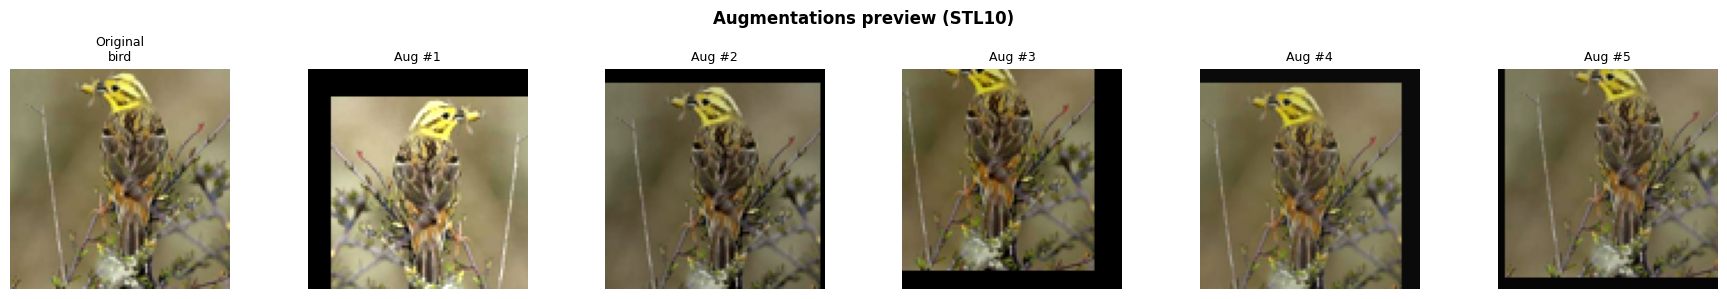

In [57]:
def show_augmentations(transform_aug, classes, n_aug: int = 5,
                       save_path: str = None):
    raw_ds = torchvision.datasets.STL10(
        root=cfg.data_dir, split="train",
        download=False, transform=None
    )

    img_pil, label = raw_ds[0]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    fig, axes = plt.subplots(1, n_aug + 1, figsize=(3 * (n_aug + 1), 3))

    # Оригинал
    axes[0].imshow(img_pil)
    axes[0].set_title(f"Original\n{classes[label]}", fontsize=9)
    axes[0].axis("off")

    # Аугментированные версии
    for i in range(n_aug):
        aug_t   = transform_aug(img_pil)
        aug_img = (aug_t * std + mean).clamp(0, 1)
        aug_np  = aug_img.permute(1, 2, 0).numpy()
        axes[i+1].imshow(aug_np)
        axes[i+1].set_title(f"Aug #{i+1}", fontsize=9)
        axes[i+1].axis("off")

    fig.suptitle("Augmentations preview (STL10)", fontsize=12, fontweight="bold")
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Сохранено: {save_path}")
    plt.show()

show_augmentations(
    transform_aug=transform_aug,
    classes=STL10_CLASSES,
    n_aug=5,
    save_path=f"{cfg.figures_dir}/augmentations_preview.png"
)